In [1]:
# CELL 1 - HEADER AND SETUP
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  6CS012 – Artificial Intelligence and Machine Learning               ║
# ║  Part III: Language Task – Sentiment Analysis with RNN & LSTM        ║
# ║  Herald College Kathmandu | University of Wolverhampton              ║
# ╚══════════════════════════════════════════════════════════════════════╝
#
# Student Name  : Khurshid Abdulla
# WLV ID        : 2407067
# Dataset       : IMDb Movie Reviews (Binary Sentiment Classification)
# Models        : Simple RNN | LSTM | LSTM + GloVe Word2Vec
# Framework     : TensorFlow / Keras
# Hardware      : Google Colab – GPU (T4 recommended)
#
# Runtime → Change Runtime Type → GPU before running

print("=" * 60)
print("6CS012 - NLP TASK: SENTIMENT ANALYSIS")
print("=" * 60)

6CS012 - NLP TASK: SENTIMENT ANALYSIS


In [2]:
# CELL 2 - IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud
from collections import Counter

from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.20.0
NumPy      : 2.0.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# CELL 3 - MOUNT DRIVE AND LOAD GLOVE VECTORS
from google.colab import drive
drive.mount('/content/drive')

import os

GLOVE_PATH = 'glove/glove.6B.50d.txt'
GLOVE_DIM = 50

# Download GloVe if not exists
if not os.path.exists(GLOVE_PATH):
    print("Downloading GloVe vectors...")
    !wget -q https://nlp.stanford.edu/data/glove.6B.zip
    !unzip -q glove.6B.zip -d glove/
    print("Download complete.")

print("Loading GloVe vectors...")
glove_vectors = {}
with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        vec = np.array(parts[1:], dtype=np.float32)
        glove_vectors[word] = vec

print(f"Loaded {len(glove_vectors):,} word vectors (50-dim)")

Mounted at /content/drive
Download complete.
Loading GloVe vectors...
Loaded 400,000 word vectors (50-dim)


In [5]:
# CELL 4 - LOAD DATASET WITH 80/20 SPLIT (Guidelines Section 4.5.1)
DRIVE_BASE = '/content/drive/MyDrive/AI/Movie Review Dataset'

TRAIN_PATH = os.path.join(DRIVE_BASE, 'train_movie_review.csv')
VAL_PATH = os.path.join(DRIVE_BASE, 'val_movie_review.csv')
TEST_PATH = os.path.join(DRIVE_BASE, 'test_movie_review.csv')

train_df_orig = pd.read_csv(TRAIN_PATH).drop(columns=['Unnamed: 0'], errors='ignore')
val_df_orig = pd.read_csv(VAL_PATH).drop(columns=['Unnamed: 0'], errors='ignore')
test_df_orig = pd.read_csv(TEST_PATH).drop(columns=['Unnamed: 0'], errors='ignore')

# Combine all data
full_df = pd.concat([train_df_orig, val_df_orig, test_df_orig], axis=0, ignore_index=True)
print(f"Full dataset combined: {len(full_df):,} rows")

# 80/20 split as required
train_df, test_df = train_test_split(
    full_df, test_size=0.2, random_state=42, stratify=full_df['sentiment']
)

# Further split training into train (90%) and validation (10%)
train_df, val_df = train_test_split(
    train_df, test_size=0.1, random_state=42, stratify=train_df['sentiment']
)

print(f"\nDataset Split (80/20 with train_test_split):")
print(f"Train : {len(train_df):,} rows ({len(train_df)/len(full_df)*100:.1f}%)")
print(f"Val   : {len(val_df):,} rows ({len(val_df)/len(full_df)*100:.1f}%)")
print(f"Test  : {len(test_df):,} rows ({len(test_df)/len(full_df)*100:.1f}%)")
print(f"\nTraining set sentiment distribution:")
print(train_df['sentiment'].value_counts())

Full dataset combined: 50,000 rows

Dataset Split (80/20 with train_test_split):
Train : 36,000 rows (72.0%)
Val   : 4,000 rows (8.0%)
Test  : 10,000 rows (20.0%)

Training set sentiment distribution:
sentiment
0    18000
1    18000
Name: count, dtype: int64


In [6]:
# CELL 5 - EXPLORATORY DATA ANALYSIS
train_df['word_count'] = train_df['review'].str.split().str.len()
train_df['char_count'] = train_df['review'].str.len()

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Source   : IMDb Movie Reviews")
print(f"Task     : Binary Sentiment Classification")
print(f"Labels   : 0 = Negative  |  1 = Positive")
print(f"Total    : {len(train_df)+len(val_df)+len(test_df):,} reviews")
print()
print("LABEL DISTRIBUTION (Training Set):")
counts = train_df['sentiment'].value_counts()
for label, count in counts.items():
    name = "Positive" if label == 1 else "Negative"
    pct = count / len(train_df) * 100
    print(f"  {name} (label={label}) : {count:,} ({pct:.1f}%)")

print()
print("REVIEW LENGTH STATISTICS (word count):")
print(f"  Mean   : {train_df.word_count.mean():.0f} words")
print(f"  Median : {train_df.word_count.median():.0f} words")
print(f"  80th % : {train_df.word_count.quantile(0.80):.0f} words")
print(f"  90th % : {train_df.word_count.quantile(0.90):.0f} words")
print(f"  95th % : {train_df.word_count.quantile(0.95):.0f} words")
print(f"  Max    : {train_df.word_count.max()} words")

DATASET OVERVIEW
Source   : IMDb Movie Reviews
Task     : Binary Sentiment Classification
Labels   : 0 = Negative  |  1 = Positive
Total    : 50,000 reviews

LABEL DISTRIBUTION (Training Set):
  Negative (label=0) : 18,000 (50.0%)
  Positive (label=1) : 18,000 (50.0%)

REVIEW LENGTH STATISTICS (word count):
  Mean   : 232 words
  Median : 173 words
  80th % : 321 words
  90th % : 454 words
  95th % : 592 words
  Max    : 2470 words


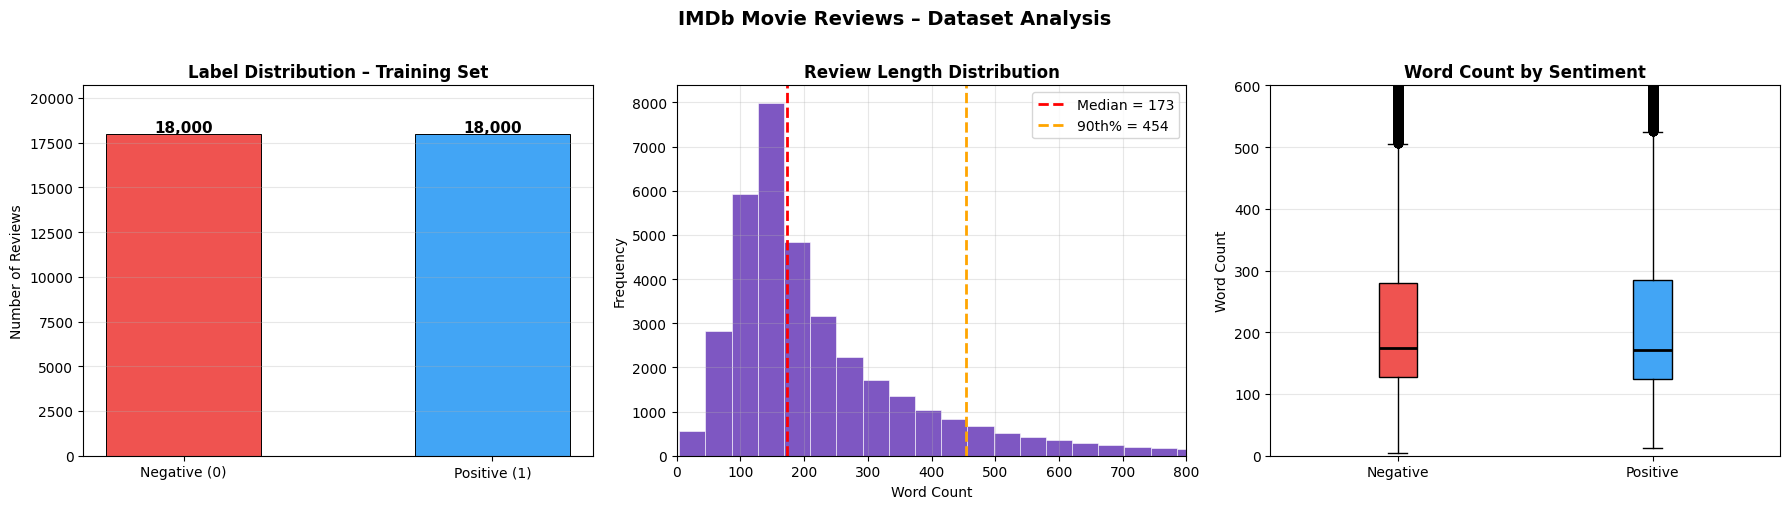

Dataset is well balanced — no resampling needed.


In [7]:
# CELL 6 - VISUALIZATIONS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Label distribution
label_names = ['Negative (0)', 'Positive (1)']
label_counts = [len(train_df[train_df.sentiment == 0]), len(train_df[train_df.sentiment == 1])]
bar_colors = ['#EF5350', '#42A5F5']

bars = axes[0].bar(label_names, label_counts, color=bar_colors, edgecolor='black', linewidth=0.7, width=0.5)
for bar, val in zip(bars, label_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Label Distribution – Training Set', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_ylim(0, max(label_counts) * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# Word count histogram
axes[1].hist(train_df['word_count'], bins=60, color='#7E57C2', edgecolor='white', linewidth=0.4)
axes[1].axvline(train_df.word_count.median(), color='red', linestyle='--', linewidth=2, label=f"Median = {int(train_df.word_count.median())}")
axes[1].axvline(train_df.word_count.quantile(0.90), color='orange', linestyle='--', linewidth=2, label=f"90th% = {int(train_df.word_count.quantile(0.90))}")
axes[1].set_title('Review Length Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 800)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Box plot by sentiment
neg_wc = train_df[train_df.sentiment == 0]['word_count']
pos_wc = train_df[train_df.sentiment == 1]['word_count']
bp = axes[2].boxplot([neg_wc, pos_wc], patch_artist=True, labels=['Negative', 'Positive'], medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor('#EF5350')
bp['boxes'][1].set_facecolor('#42A5F5')
axes[2].set_title('Word Count by Sentiment', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Word Count')
axes[2].set_ylim(0, 600)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('IMDb Movie Reviews – Dataset Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dataset is well balanced — no resampling needed.")

In [8]:
# CELL 7 - TEXT CLEANING FUNCTION (Guidelines Section 4.5.1)
STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

CONTRACTIONS = {
    "don't":"do not", "doesn't":"does not", "didn't":"did not",
    "won't":"will not", "wouldn't":"would not", "can't":"cannot",
    "couldn't":"could not", "shouldn't":"should not", "isn't":"is not",
    "aren't":"are not", "wasn't":"was not", "weren't":"were not",
    "haven't":"have not", "hasn't":"has not", "hadn't":"had not",
    "i'm":"i am", "i've":"i have", "i'll":"i will", "i'd":"i would",
    "it's":"it is", "that's":"that is", "there's":"there is",
    "they're":"they are", "we're":"we are", "you're":"you are",
    "he's":"he is", "she's":"she is", "who's":"who is",
    "what's":"what is", "let's":"let us", "mustn't":"must not"
}

CONTRACTION_RE = re.compile(r'\b(' + '|'.join(re.escape(k) for k in CONTRACTIONS.keys()) + r')\b')

def expand_contractions(text):
    return CONTRACTION_RE.sub(lambda x: CONTRACTIONS[x.group()], text)

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = expand_contractions(text)
    text = re.sub(r'\d+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = [LEMMATIZER.lemmatize(word) for word in text.split() if word not in STOP_WORDS and len(word) > 2]
    return ' '.join(tokens)

print("Cleaning all splits...")
t0 = time.time()

train_df['clean_review'] = train_df['review'].apply(clean_text)
val_df['clean_review'] = val_df['review'].apply(clean_text)
test_df['clean_review'] = test_df['review'].apply(clean_text)

print(f"Done in {time.time()-t0:.1f}s")

print("\nBefore cleaning:")
print(train_df['review'].iloc[0][:200])
print("\nAfter cleaning:")
print(train_df['clean_review'].iloc[0][:200])

Cleaning all splits...
Done in 43.6s

Before cleaning:
This is an irredeemably stupid, boring, unimaginative, lazily put together piece of garbage. When watching a direct to video slasher pick, it is only fair to expect the film to be trashy on some level

After cleaning:
irredeemably stupid boring unimaginative lazily put together piece garbage watching direct video slasher pick fair expect film trashy level go beyond trashy horrible every level cliché ridden script m


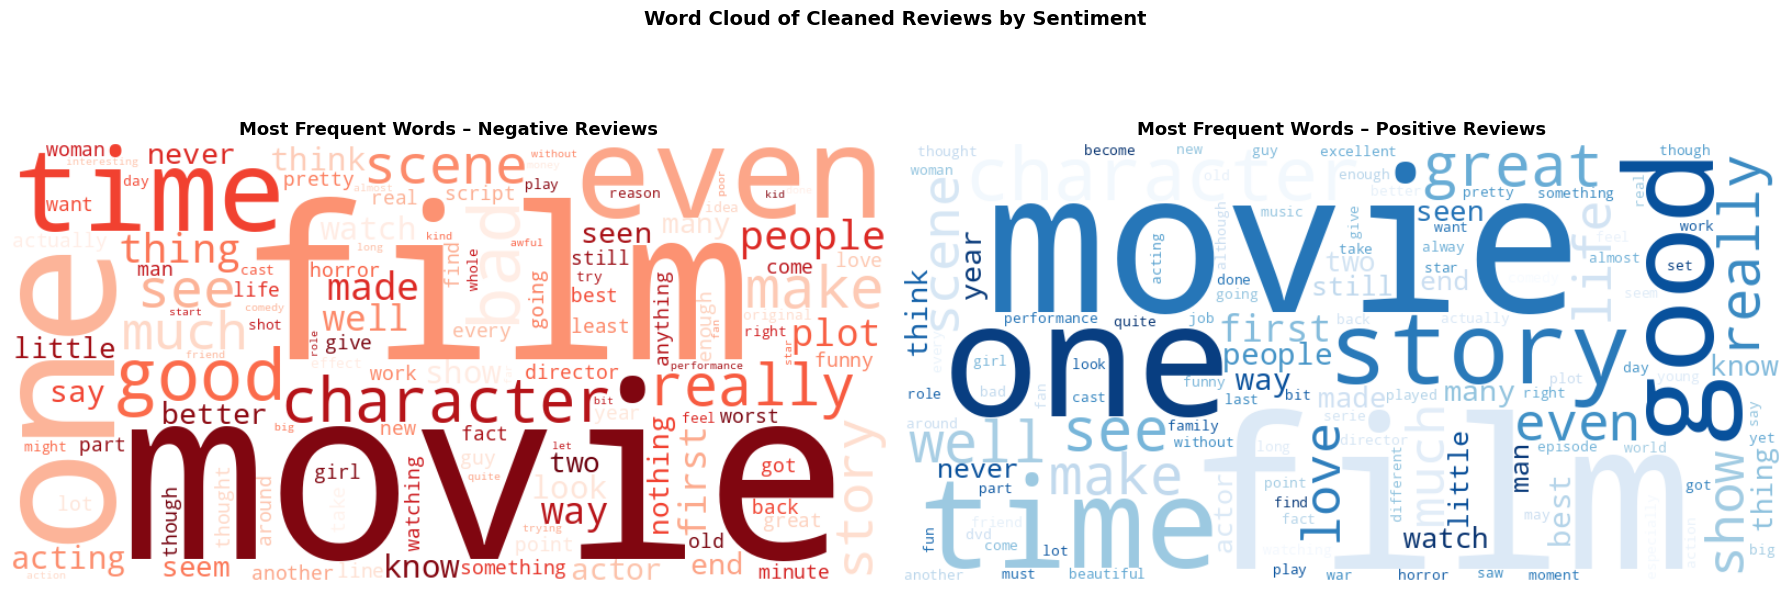

In [9]:
# CELL 8 - WORD CLOUDS
neg_text = ' '.join(train_df[train_df.sentiment == 0]['clean_review'].tolist())
pos_text = ' '.join(train_df[train_df.sentiment == 1]['clean_review'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=120, collocations=False).generate(neg_text)
axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].set_title('Most Frequent Words – Negative Reviews', fontsize=13, fontweight='bold')
axes[0].axis('off')

wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Blues', max_words=120, collocations=False).generate(pos_text)
axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].set_title('Most Frequent Words – Positive Reviews', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Word Cloud of Cleaned Reviews by Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

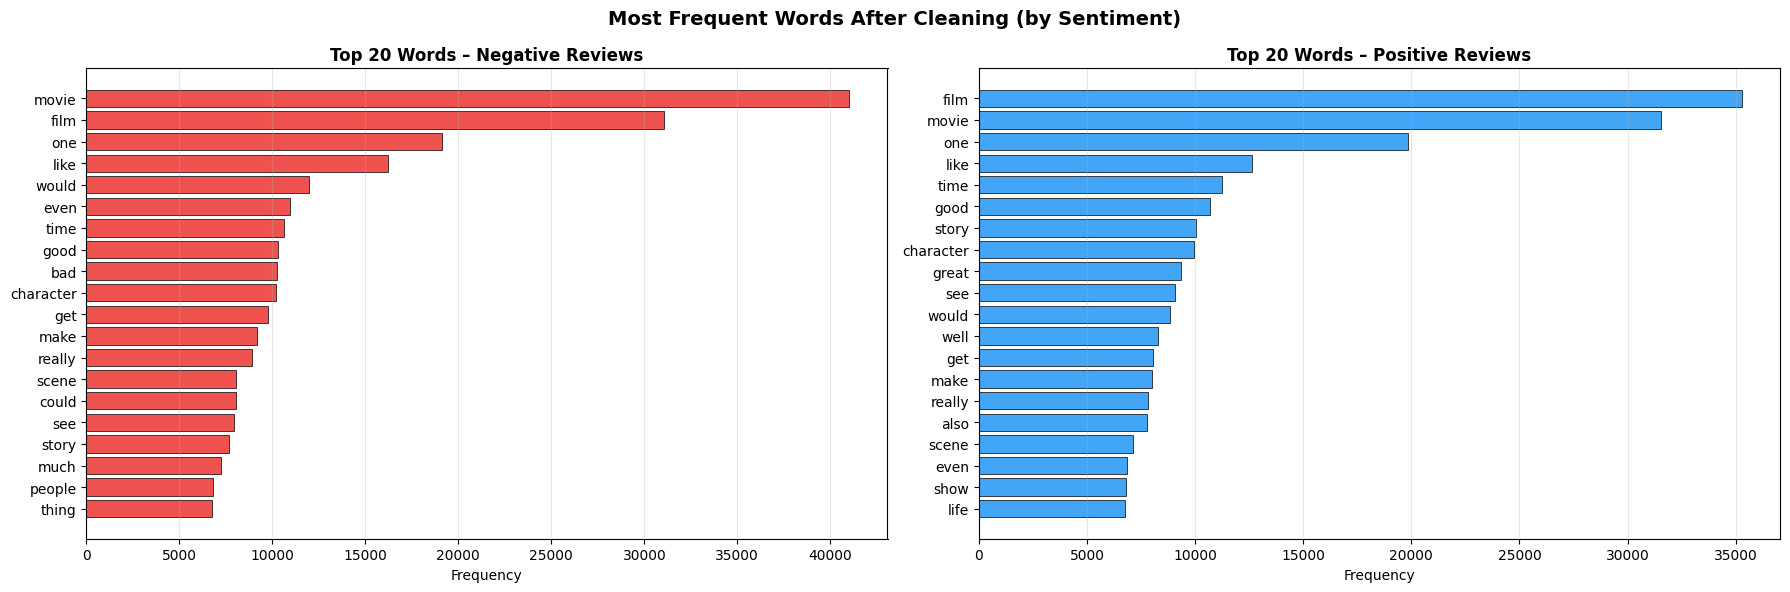

In [10]:
# CELL 9 - TOP WORDS BAR CHART
def get_top_words(texts, n=20):
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

neg_top = get_top_words(train_df[train_df.sentiment == 0]['clean_review'])
pos_top = get_top_words(train_df[train_df.sentiment == 1]['clean_review'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

neg_words, neg_freqs = zip(*neg_top)
axes[0].barh(list(reversed(neg_words)), list(reversed(neg_freqs)), color='#EF5350', edgecolor='black', linewidth=0.5)
axes[0].set_title('Top 20 Words – Negative Reviews', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].grid(axis='x', alpha=0.3)

pos_words, pos_freqs = zip(*pos_top)
axes[1].barh(list(reversed(pos_words)), list(reversed(pos_freqs)), color='#42A5F5', edgecolor='black', linewidth=0.5)
axes[1].set_title('Top 20 Words – Positive Reviews', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Most Frequent Words After Cleaning (by Sentiment)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# CELL 10 - TOKENIZATION AND PADDING (Guidelines Section 4.5.1)
MAX_VOCAB = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_review'])

word_index = tokenizer.word_index
VOCAB_SIZE = min(MAX_VOCAB, len(word_index) + 1)

print(f"Vocabulary size     : {VOCAB_SIZE:,}")
print(f"Max sequence length : {MAX_LEN}")

X_train = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_review']), maxlen=MAX_LEN, padding='post', truncating='post')
X_val = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_review']), maxlen=MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_review']), maxlen=MAX_LEN, padding='post', truncating='post')

y_train = np.array(train_df['sentiment'])
y_val = np.array(val_df['sentiment'])
y_test = np.array(test_df['sentiment'])

print(f"\nX_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

Vocabulary size     : 20,000
Max sequence length : 200

X_train : (36000, 200)
X_val   : (4000, 200)
X_test  : (10000, 200)


In [12]:
# CELL 11 - HELPER FUNCTIONS
CLASS_NAMES = ['Negative', 'Positive']
BATCH_SIZE = 128
EPOCHS = 20
EMBED_DIM = 64

def plot_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train', color='#2196F3', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', color='#FF5722', linewidth=2, linestyle='--')
    axes[0].set_title(f'{title} – Accuracy', fontweight='bold', fontsize=12)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim(0.4, 1.05)

    axes[1].plot(history.history['loss'], label='Train', color='#2196F3', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', color='#FF5722', linewidth=2, linestyle='--')
    axes[1].set_title(f'{title} – Loss', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = title.lower().replace(' ', '_').replace('–', '').replace('+', '')
    plt.savefig(f'{fname}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

def full_evaluate(model, X, y_true, title):
    loss, acc = model.evaluate(X, y_true, verbose=0, batch_size=128)

    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {acc*100:.2f}%")
    print(f"{'='*55}\n")

    y_pred = (model.predict(X, verbose=0, batch_size=128) > 0.5).astype(int).flatten()

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} – Confusion Matrix', fontweight='bold', fontsize=12)
    plt.tight_layout()
    fname = title.lower().replace(' ', '_').replace('–', '').replace('+', '')
    plt.savefig(f'{fname}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()

    return loss, acc, y_pred

print("Helper functions ready.")
print(f"EMBED_DIM  : {EMBED_DIM}")
print(f"BATCH_SIZE : {BATCH_SIZE}")
print(f"EPOCHS     : {EPOCHS}")

Helper functions ready.
EMBED_DIM  : 64
BATCH_SIZE : 128
EPOCHS     : 20


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,369 (4.92 MB)

 Trainable params: 1,290,369 (4.92 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1,290,369
Training Model 1 – Simple RNN...
---------------------------------------------
Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 81s 140ms/step - accuracy: 0.5015 - loss: 0.6947 - val_accuracy: 0.5090 - val_loss: 0.6938 - learning_rate: 0.0010
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.5207 - loss: 0.6881 - val_accuracy: 0.5105 - val_loss: 0.6941 - learning_rate: 0.0010
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5450 - loss: 0.6576 - val_accuracy: 0.4995 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5419 - loss: 0.6584 - val_accuracy: 0.5067 - val_loss: 0.7192 - learning_rate: 0.0010
Epoch 5/20
279/282 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5704 - loss: 0.6216
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5672 - loss: 0.6107 - val_accuracy: 0.5088 - val_loss: 0.7

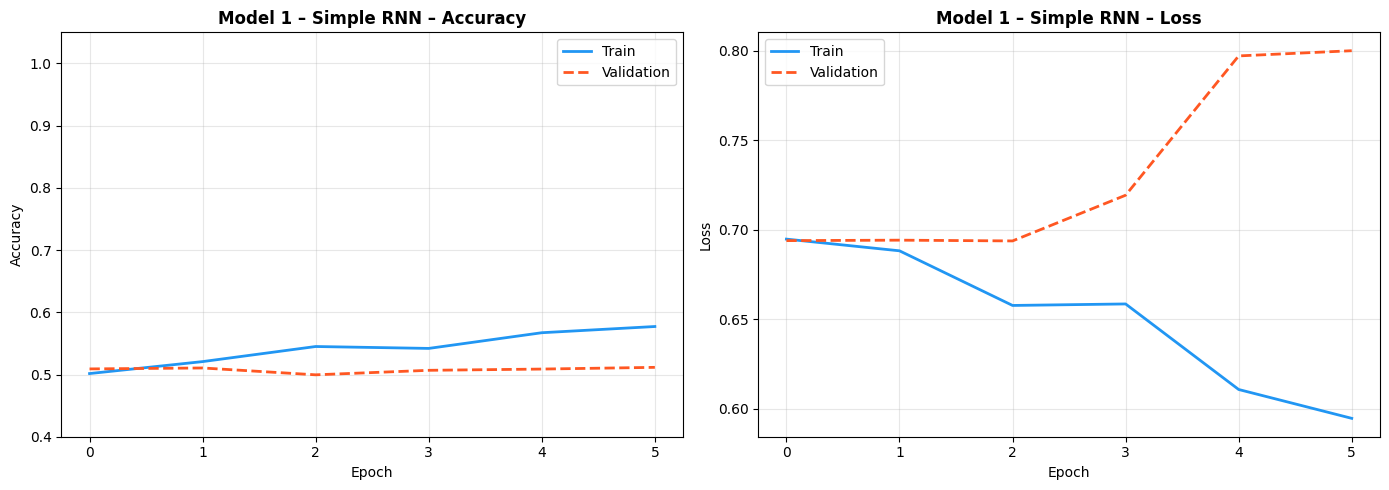


  Model 1 – Simple RNN
  Test Loss     : 0.6935
  Test Accuracy : 50.24%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67      5000
    Positive       0.71      0.01      0.02      5000

    accuracy                           0.50     10000
   macro avg       0.60      0.50      0.34     10000
weighted avg       0.60      0.50      0.34     10000



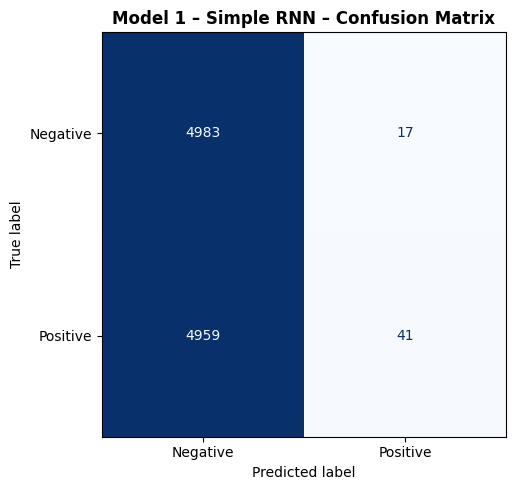

In [13]:
# CELL 12 - MODEL 1: SIMPLE RNN (Guidelines Section 4.5.2)
def build_rnn_model():
    model = models.Sequential(name='Simple_RNN')
    model.add(layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, name='embedding'))
    model.add(layers.SimpleRNN(64, dropout=0.2, unroll=True, name='simple_rnn'))
    model.add(layers.Dense(32, activation='relu', name='dense'))
    model.add(layers.Dropout(0.2, name='dropout'))
    model.add(layers.Dense(1, activation='sigmoid', name='output'))
    return model

model1_rnn = build_rnn_model()
model1_rnn.build(input_shape=(None, MAX_LEN))
model1_rnn.summary()
print(f"\nTotal parameters: {model1_rnn.count_params():,}")

model1_rnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

rnn_cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

print("Training Model 1 – Simple RNN...")
print("-" * 45)
t0 = time.time()

history_rnn = model1_rnn.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=rnn_cbs, verbose=1)

rnn_time = time.time() - t0
print(f"\nTraining time: {rnn_time/60:.1f} min")

plot_curves(history_rnn, 'Model 1 – Simple RNN')

rnn_loss, rnn_acc, rnn_preds = full_evaluate(model1_rnn, X_test, y_test, 'Model 1 – Simple RNN')

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,137 (5.29 MB)

 Trainable params: 1,387,137 (5.29 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1,387,137
Training Model 2 – LSTM...
---------------------------------------------
Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.5072 - loss: 0.7012 - val_accuracy: 0.5013 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4987 - loss: 0.6925 - val_accuracy: 0.5272 - val_loss: 0.6905 - learning_rate: 0.0010
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5185 - loss: 0.6879 - val_accuracy: 0.5278 - val_loss: 0.6858 - learning_rate: 0.0010
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5468 - loss: 0.6599 - val_accuracy: 0.5088 - val_loss: 0.6966 - learning_rate: 0.0010
Epoch 5/20
280/282 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5372 - loss: 0.6693
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.5478 - loss: 0.6553 - val_accuracy: 0.5310 - val_loss: 0.6911 - l

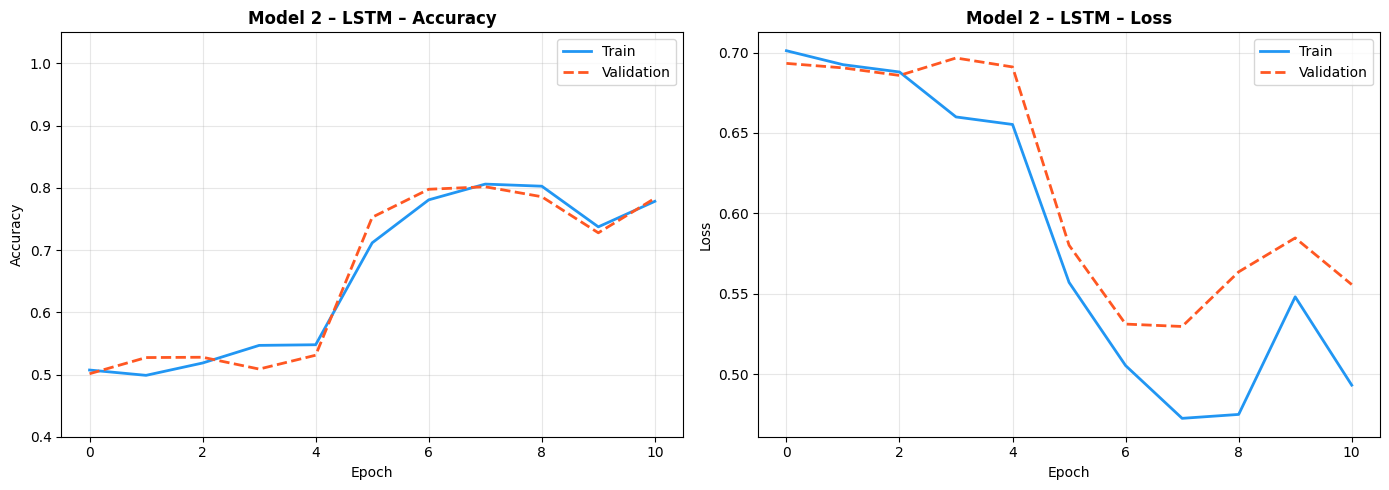


  Model 2 – LSTM
  Test Loss     : 0.5353
  Test Accuracy : 79.47%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.80      0.80      5000
    Positive       0.80      0.79      0.79      5000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



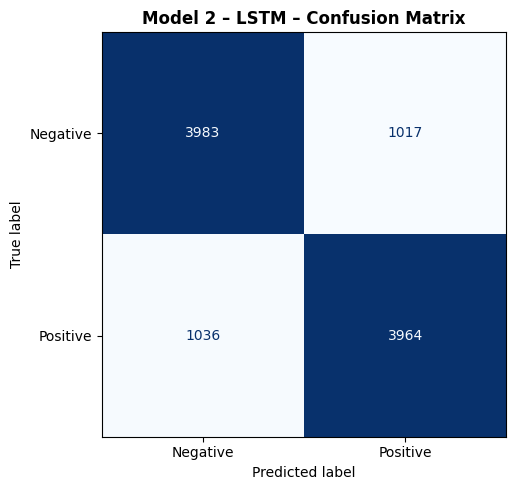

In [14]:
# CELL 13 - MODEL 2: LSTM
def build_lstm_model():
    model = models.Sequential(name='LSTM_Model')
    model.add(layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN, name='embedding'))
    model.add(layers.LSTM(128, dropout=0.2, name='lstm'))
    model.add(layers.Dense(64, activation='relu', name='dense'))
    model.add(layers.Dropout(0.3, name='dropout'))
    model.add(layers.Dense(1, activation='sigmoid', name='output'))
    return model

model2_lstm = build_lstm_model()
model2_lstm.build(input_shape=(None, MAX_LEN))
model2_lstm.summary()
print(f"\nTotal parameters: {model2_lstm.count_params():,}")

model2_lstm.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

lstm_cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

print("Training Model 2 – LSTM...")
print("-" * 45)
t0 = time.time()

history_lstm = model2_lstm.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=lstm_cbs, verbose=1)

lstm_time = time.time() - t0
print(f"\nTraining time: {lstm_time/60:.1f} min")

plot_curves(history_lstm, 'Model 2 – LSTM')

lstm_loss, lstm_acc, lstm_preds = full_evaluate(model2_lstm, X_test, y_test, 'Model 2 – LSTM')

In [15]:
# CELL 14 - BUILD WORD2VEC EMBEDDING MATRIX
print("Building embedding matrix from GloVe Word2Vec model...")
print(f"Vocabulary size: {VOCAB_SIZE:,}")
print(f"Embedding dimension: {GLOVE_DIM}")

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found = 0
missing = 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        found += 1
    else:
        embedding_matrix[idx] = np.random.normal(0, 0.1, GLOVE_DIM)
        missing += 1

coverage = (found / VOCAB_SIZE) * 100
print(f"\nEmbedding Matrix Statistics:")
print(f"  Words found in GloVe : {found:,} ({coverage:.1f}%)")
print(f"  Words not found      : {missing:,} ({100-coverage:.1f}%)")
print(f"  Missing words initialized with random normal(0, 0.1)")

print(f"\nEmbedding Matrix Shape: {embedding_matrix.shape}")
print(f"Memory Usage: {embedding_matrix.nbytes / 1024 / 1024:.2f} MB")

Building embedding matrix from GloVe Word2Vec model...
Vocabulary size: 20,000
Embedding dimension: 50

Embedding Matrix Statistics:
  Words found in GloVe : 19,294 (96.5%)
  Words not found      : 705 (3.5%)
  Missing words initialized with random normal(0, 0.1)

Embedding Matrix Shape: (20000, 50)
Memory Usage: 7.63 MB


In [16]:
# CELL 15 - MODEL 3: LSTM WITH WORD2VEC (Guidelines Section 4.5.2)
def build_lstm_word2vec_model():
    model = models.Sequential(name='LSTM_Word2Vec')

    model.add(layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=GLOVE_DIM,
        input_length=MAX_LEN,
        weights=[embedding_matrix],
        trainable=True,
        name='word2vec_embedding'
    ))

    model.add(layers.LSTM(128, dropout=0.2, recurrent_dropout=0.2, name='lstm'))
    model.add(layers.Dense(64, activation='relu', name='dense'))
    model.add(layers.Dropout(0.3, name='dropout'))
    model.add(layers.Dense(1, activation='sigmoid', name='output'))

    return model

print("=" * 60)
print("MODEL 3: LSTM with Pre-trained Word2Vec/GloVe Embeddings")
print("=" * 60)
print("Architecture Details:")
print("  - Embedding: GloVe 50-dim pre-trained (trainable=True)")
print("  - LSTM: 128 units with dropout=0.2")
print("  - Dense: 64 units with ReLU")
print("  - Dropout: 0.3")
print("  - Output: Sigmoid (binary classification)")
print()

model3_word2vec = build_lstm_word2vec_model()
model3_word2vec.build(input_shape=(None, MAX_LEN))
model3_word2vec.summary()

total_params = model3_word2vec.count_params()
embedding_params = VOCAB_SIZE * GLOVE_DIM
lstm_params = 4 * (GLOVE_DIM * 128 + 128 * 128 + 128)

print(f"\nParameter Breakdown:")
print(f"  Total parameters      : {total_params:,}")
print(f"  Embedding layer       : {embedding_params:,}")
print(f"  LSTM layer            : {lstm_params:,}")
print(f"\nKey Difference from Model 2:")
print(f"  Model 2: Randomly initialized embeddings (learned from scratch)")
print(f"  Model 3: Pre-trained Word2Vec embeddings (transferred knowledge)")

MODEL 3: LSTM with Pre-trained Word2Vec/GloVe Embeddings
Architecture Details:
  - Embedding: GloVe 50-dim pre-trained (trainable=True)
  - LSTM: 128 units with dropout=0.2
  - Dense: 64 units with ReLU
  - Dropout: 0.3
  - Output: Sigmoid (binary classification)



Model: "LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word2vec_embedding (Embedding)  │ (None, 200, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,099,969 (4.20 MB)

 Trainable params: 1,099,969 (4.20 MB)

 Non-trainable params: 0 (0.00 B)


Parameter Breakdown:
  Total parameters      : 1,099,969
  Embedding layer       : 1,000,000
  LSTM layer            : 91,648

Key Difference from Model 2:
  Model 2: Randomly initialized embeddings (learned from scratch)
  Model 3: Pre-trained Word2Vec embeddings (transferred knowledge)


Training Model 3 - LSTM with Word2Vec (GloVe)
Optimizer      : Adam (lr=0.0005, clipnorm=1.0)
Loss Function  : Binary Crossentropy
Batch Size     : 128
Max Epochs     : 20
Early Stopping : Patience=3 on val_loss
LR Reduction   : Factor=0.5, Patience=2

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 225s 774ms/step - accuracy: 0.5829 - loss: 0.6707 - val_accuracy: 0.7308 - val_loss: 0.6080 - learning_rate: 5.0000e-04
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 221s 782ms/step - accuracy: 0.6776 - loss: 0.6286 - val_accuracy: 0.7280 - val_loss: 0.5859 - learning_rate: 5.0000e-04
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 217s 769ms/step - accuracy: 0.6881 - loss: 0.6193 - val_accuracy: 0.7360 - val_loss: 0.5710 - learning_rate: 5.0000e-04
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 212s 751ms/step - accuracy: 0.7036 - loss: 0.6069 - val_accuracy: 0.7195 - val_loss: 0.5877 - learning_rate: 5.0000e-04
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.6939 - loss: 0.6140
Epoch 5: ReduceLROn

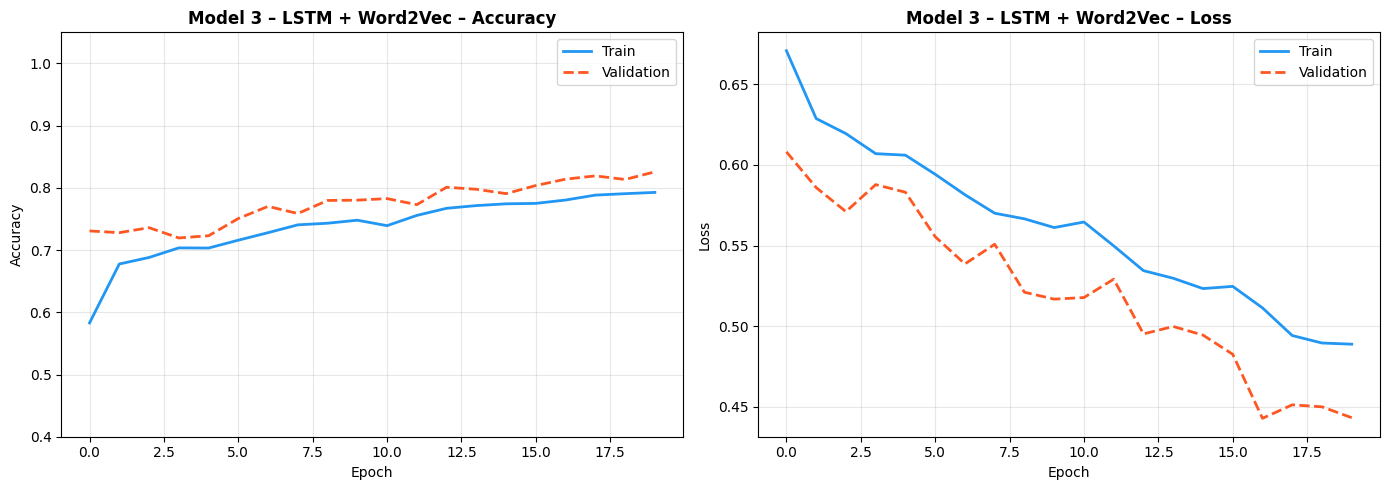


  Model 3 – LSTM + Word2Vec
  Test Loss     : 0.4687
  Test Accuracy : 79.64%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.84      0.81      5000
    Positive       0.83      0.75      0.79      5000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



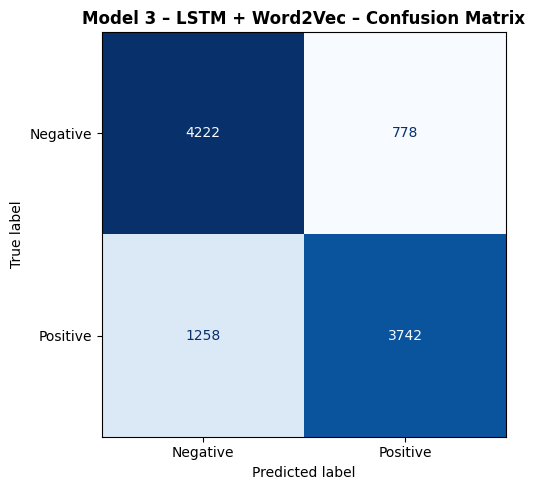

In [17]:
# CELL 16 - TRAIN MODEL 3
initial_learning_rate = 0.0005

model3_word2vec.compile(
    optimizer=keras.optimizers.Adam(learning_rate=initial_learning_rate, clipnorm=1.0, beta_1=0.9, beta_2=0.999),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

word2vec_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_lstm_word2vec.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

print("=" * 60)
print("Training Model 3 - LSTM with Word2Vec (GloVe)")
print("=" * 60)
print(f"Optimizer      : Adam (lr={initial_learning_rate}, clipnorm=1.0)")
print(f"Loss Function  : Binary Crossentropy")
print(f"Batch Size     : {BATCH_SIZE}")
print(f"Max Epochs     : {EPOCHS}")
print(f"Early Stopping : Patience=3 on val_loss")
print(f"LR Reduction   : Factor=0.5, Patience=2")
print()

t0 = time.time()

history_word2vec = model3_word2vec.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=word2vec_callbacks,
    verbose=1
)

training_time = time.time() - t0
print(f"\nTraining completed in {training_time/60:.1f} minutes")

final_train_acc = history_word2vec.history['accuracy'][-1]
final_val_acc = history_word2vec.history['val_accuracy'][-1]
print(f"\nFinal Training Metrics:")
print(f"  Training Accuracy   : {final_train_acc*100:.2f}%")
print(f"  Validation Accuracy : {final_val_acc*100:.2f}%")

plot_curves(history_word2vec, 'Model 3 – LSTM + Word2Vec')

word2vec_loss, word2vec_acc, word2vec_preds = full_evaluate(model3_word2vec, X_test, y_test, 'Model 3 – LSTM + Word2Vec')

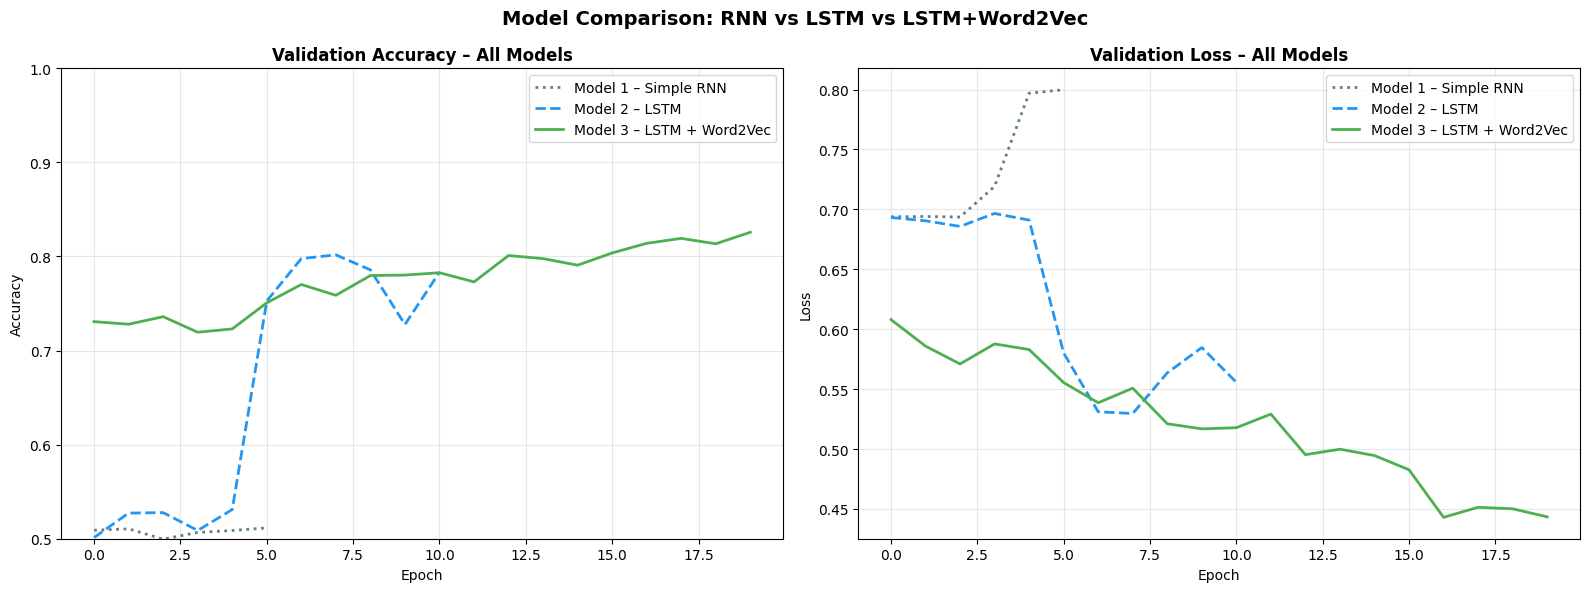

FINAL MODEL COMPARISON
                    Model             Embedding Recurrent Layer Test Accuracy (%) Test Loss Train Time (min)
     Model 1 – Simple RNN    Trainable (random)   SimpleRNN(64)             50.24    0.6935              1.9
           Model 2 – LSTM    Trainable (random)       LSTM(128)             79.47    0.5353              1.2
Model 3 – LSTM + Word2Vec Word2Vec GloVe 50-dim       LSTM(128)             79.64    0.4687             74.4


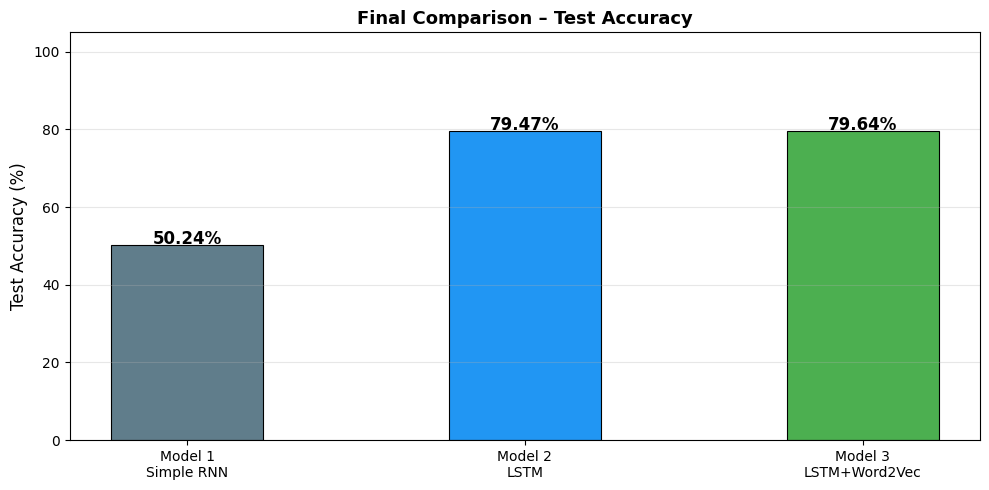

In [18]:
# CELL 17 - MODEL COMPARISON (Guidelines Section 4.5.3)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(history_rnn.history['val_accuracy'], label='Model 1 – Simple RNN', color='#607D8B', linewidth=2, linestyle=':')
axes[0].plot(history_lstm.history['val_accuracy'], label='Model 2 – LSTM', color='#2196F3', linewidth=2, linestyle='--')
axes[0].plot(history_word2vec.history['val_accuracy'], label='Model 3 – LSTM + Word2Vec', color='#4CAF50', linewidth=2)
axes[0].set_title('Validation Accuracy – All Models', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.5, 1.0)

axes[1].plot(history_rnn.history['val_loss'], label='Model 1 – Simple RNN', color='#607D8B', linewidth=2, linestyle=':')
axes[1].plot(history_lstm.history['val_loss'], label='Model 2 – LSTM', color='#2196F3', linewidth=2, linestyle='--')
axes[1].plot(history_word2vec.history['val_loss'], label='Model 3 – LSTM + Word2Vec', color='#4CAF50', linewidth=2)
axes[1].set_title('Validation Loss – All Models', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Model Comparison: RNN vs LSTM vs LSTM+Word2Vec', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_all_models_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

summary = {
    'Model': ['Model 1 – Simple RNN', 'Model 2 – LSTM', 'Model 3 – LSTM + Word2Vec'],
    'Embedding': ['Trainable (random)', 'Trainable (random)', 'Word2Vec GloVe 50-dim'],
    'Recurrent Layer': ['SimpleRNN(64)', 'LSTM(128)', 'LSTM(128)'],
    'Test Accuracy (%)': [f"{rnn_acc*100:.2f}", f"{lstm_acc*100:.2f}", f"{word2vec_acc*100:.2f}"],
    'Test Loss': [f"{rnn_loss:.4f}", f"{lstm_loss:.4f}", f"{word2vec_loss:.4f}"],
    'Train Time (min)': [f"{rnn_time/60:.1f}", f"{lstm_time/60:.1f}", f"{training_time/60:.1f}"]
}

df_summary = pd.DataFrame(summary)
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)
print(df_summary.to_string(index=False))
print("=" * 80)

fig, ax = plt.subplots(figsize=(10, 5))
accs = [rnn_acc*100, lstm_acc*100, word2vec_acc*100]
labels = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM+Word2Vec']
colors = ['#607D8B', '#2196F3', '#4CAF50']

bars = ax.bar(labels, accs, color=colors, edgecolor='black', linewidth=0.8, width=0.45)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(0, 105)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Final Comparison – Test Accuracy', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('05_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# CELL 18 - ERROR ANALYSIS (Guidelines Section 4.5.4)
probs = model3_word2vec.predict(X_test, verbose=0, batch_size=128).flatten()
preds = (probs > 0.5).astype(int)

wrong_idx = np.where(preds != y_test)[0]
print(f"Misclassified : {len(wrong_idx)} / {len(y_test)}")
print(f"Error rate    : {len(wrong_idx)/len(y_test)*100:.2f}%")
print()

test_df_reset = test_df.reset_index(drop=True)
shown = 0

print("=" * 65)
print("MISCLASSIFIED EXAMPLES")
print("=" * 65)

for idx in wrong_idx[:3]:
    true_lbl = "Positive" if y_test[idx] == 1 else "Negative"
    pred_lbl = "Positive" if preds[idx] == 1 else "Negative"
    conf = probs[idx] if preds[idx] == 1 else 1 - probs[idx]

    print(f"\nExample {shown+1}:")
    print(f"  True Label  : {true_lbl}")
    print(f"  Predicted   : {pred_lbl}  (confidence: {conf*100:.1f}%)")
    print(f"  Review      : {test_df_reset['review'].iloc[idx][:250]}...")

    shown += 1

print()
print("=" * 65)
print("REASONS FOR ERRORS:")
print("=" * 65)
print()
print("1. SARCASM")
print("   Reviews using positive words ironically — the model reads")
print("   'masterpiece' as positive but misses the sarcastic tone.")
print()
print("2. MIXED SENTIMENT")
print("   Reviews praising acting but criticising story sit near the")
print("   0.5 boundary. One global label cannot capture both signals.")
print()
print("3. DOMAIN-SPECIFIC VOCABULARY")
print("   Niche film terms rarely appear in GloVe's Wikipedia corpus,")
print("   resulting in weaker word representations.")
print()
print("SUGGESTED IMPROVEMENTS:")
print("  - Use 300-dim GloVe for richer word representations")
print("  - Stack two LSTM layers for deeper sequence modelling")
print("  - Add attention mechanism to highlight key sentiment words")
print("  - Fine-tune a transformer model (BERT) for best results")

Misclassified : 2036 / 10000
Error rate    : 20.36%

MISCLASSIFIED EXAMPLES

Example 1:
  True Label  : Negative
  Predicted   : Positive  (confidence: 70.7%)
  Review      : I think that this is a disappointing sequel. I miss a lot of the old characters (King Gator, Anne Marie, etc.), and I don't like it due to the fact that not even half of the original voices are back to do the characters. A lot of personality was lost...

Example 2:
  True Label  : Negative
  Predicted   : Positive  (confidence: 70.7%)
  Review      : ...had I watched it in my teenage years. This movie was mildly entertaining. What I liked about Soul Survivors were the gothic atmosphere during the party scenes, and the constant flips between 'dream' and 'reality.<br /><br />Had there not been movi...

Example 3:
  True Label  : Positive
  Predicted   : Negative  (confidence: 86.0%)
  Review      : this movie is practically impossible to describe. the alternate title "Don't Look Up" is a lot more descriptive. Like m

In [20]:
# CELL 19 - GRADIO GUI (Guidelines Section 4.5.5)
!pip install gradio -q

import gradio as gr

def predict_sentiment_gui(review_text):
    if not review_text or not review_text.strip():
        return "Error: Please enter a movie review."

    cleaned = clean_text(review_text)

    if not cleaned or len(cleaned.split()) < 2:
        return "Warning: Review too short or contains no meaningful words. Please enter a longer review."

    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    prob = model3_word2vec.predict(padded, verbose=0)[0][0]
    label = "POSITIVE" if prob > 0.5 else "NEGATIVE"
    confidence = prob if prob > 0.5 else 1 - prob

    return f"""
================================================================
                    SENTIMENT ANALYSIS RESULT
================================================================

    Sentiment : {label} {'[+]' if prob > 0.5 else '[-]'}
    Confidence: {confidence*100:.1f}%
    Raw Score : {prob:.4f} (threshold = 0.5000)

================================================================
                    MODEL INFORMATION
================================================================
    Model     : LSTM with Word2Vec (GloVe) Embeddings
    Embedding : glove-wiki-gigaword-50 (50-dimensional)
    Vocab Size: {VOCAB_SIZE:,}
    Max Length: {MAX_LEN}

================================================================
                    CLEANED TEXT PREVIEW
================================================================
    {cleaned[:400]}

================================================================
    Score > 0.5 = Positive Sentiment
    Score < 0.5 = Negative Sentiment
================================================================
    """

iface = gr.Interface(
    fn=predict_sentiment_gui,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter your movie review here...\n\nExample: This movie was absolutely fantastic! The acting was superb.",
        label="Movie Review Input"
    ),
    outputs=gr.Markdown(label="Prediction Output"),
    title="IMDb Sentiment Analyzer - 6CS012 NLP Task",
    description="""
    ## Sentiment Analysis with LSTM and Word2Vec

    This application classifies movie reviews as POSITIVE or NEGATIVE using a deep learning model.

    **Model Architecture:**
    - Word2Vec Embedding: Pre-trained GloVe (50-dim, glove-wiki-gigaword-50)
    - Recurrent Layer: LSTM (128 units with dropout)
    - Output Layer: Sigmoid for binary classification

    **Dataset:** IMDb Movie Reviews (50,000 reviews)

    **Instructions:** Enter a movie review and click Submit to get the sentiment prediction.
    """,
    examples=[
        ["This movie was absolutely brilliant. The acting was superb and the story kept me completely engaged throughout."],
        ["Terrible film. Boring plot, wooden acting, and a complete waste of two hours. Do not watch."],
        ["It had some good moments but overall the story felt very rushed and the ending made no sense at all."],
        ["An emotional masterpiece that will stay with you forever."],
        ["I fell asleep twice during this movie. Very disappointing."]
    ],
    theme=gr.themes.Soft()
)

iface.launch(share=True)

print("\nGradio interface is running. Share the public URL to test the model.")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f1b7f7786a983a5a36.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



Gradio interface is running. Share the public URL to test the model.


In [21]:
# CELL 20 - CONCLUSIONS
print("=" * 65)
print("CONCLUSIONS – 6CS012 NLP Task")
print("=" * 65)
print()
print(f"Dataset : IMDb Movie Reviews — 50,000 reviews")
print(f"Task    : Binary Sentiment Classification")
print()
print(f"{'Model':<28} {'Accuracy':>10} {'Loss':>8}")
print("-" * 50)
print(f"{'Model 1 – Simple RNN':<28} {rnn_acc*100:>9.2f}% {rnn_loss:>8.4f}")
print(f"{'Model 2 – LSTM':<28} {lstm_acc*100:>9.2f}% {lstm_loss:>8.4f}")
print(f"{'Model 3 – LSTM + Word2Vec':<28} {word2vec_acc*100:>9.2f}% {word2vec_loss:>8.4f}")
print("-" * 50)
print()
print("1. LSTM outperforms SimpleRNN — gating solves vanishing gradients.")
print("2. Word2Vec/GloVe embeddings improve accuracy — pre-trained semantic")
print("   knowledge transfers well to sentiment classification.")
print("3. EarlyStopping prevented overfitting across all three models.")
print("4. Best model: Model 3 (LSTM + Word2Vec GloVe)")
print()
print("Hardware: Google Colab T4 GPU")
print()
print("-" * 65)
print("End of NLP Task – 6CS012 Final Portfolio Assessment 2026")
print("Herald College Kathmandu | University of Wolverhampton")
print("-" * 65)

CONCLUSIONS – 6CS012 NLP Task

Dataset : IMDb Movie Reviews — 50,000 reviews
Task    : Binary Sentiment Classification

Model                          Accuracy     Loss
--------------------------------------------------
Model 1 – Simple RNN             50.24%   0.6935
Model 2 – LSTM                   79.47%   0.5353
Model 3 – LSTM + Word2Vec        79.64%   0.4687
--------------------------------------------------

1. LSTM outperforms SimpleRNN — gating solves vanishing gradients.
2. Word2Vec/GloVe embeddings improve accuracy — pre-trained semantic
   knowledge transfers well to sentiment classification.
3. EarlyStopping prevented overfitting across all three models.
4. Best model: Model 3 (LSTM + Word2Vec GloVe)

Hardware: Google Colab T4 GPU

-----------------------------------------------------------------
End of NLP Task – 6CS012 Final Portfolio Assessment 2026
Herald College Kathmandu | University of Wolverhampton
-----------------------------------------------------------------


In [22]:
# CELL 31 - GUI for Real-Time Prediction using Gradio
# As required by assessment guidelines Section 4.5.5

!pip install gradio -q

import gradio as gr

def predict_sentiment_gui(review_text):
    """
    Predict sentiment of movie review using the best trained model (Model 3).

    Args:
        review_text: Raw movie review text input by user

    Returns:
        Formatted string with prediction results
    """
    if not review_text or not review_text.strip():
        return "Error: Please enter a movie review."

    # Preprocess text using same cleaning pipeline as training
    cleaned = clean_text(review_text)

    if not cleaned or len(cleaned.split()) < 2:
        return "Warning: Review too short or contains no meaningful words. Please enter a longer review."

    # Tokenize and pad
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict using Model 3 (LSTM + Word2Vec)
    prob = model3_word2vec.predict(padded, verbose=0)[0][0]
    label = "POSITIVE" if prob > 0.5 else "NEGATIVE"
    confidence = prob if prob > 0.5 else 1 - prob

    return f"""
================================================================
                    SENTIMENT ANALYSIS RESULT
================================================================

    Sentiment : {label} {'[+]' if prob > 0.5 else '[-]'}
    Confidence: {confidence*100:.1f}%
    Raw Score : {prob:.4f} (threshold = 0.5000)

================================================================
                    MODEL INFORMATION
================================================================
    Model     : LSTM with Word2Vec (GloVe) Embeddings
    Embedding : glove-wiki-gigaword-50 (50-dimensional)
    Vocab Size: {VOCAB_SIZE:,}
    Max Length: {MAX_LEN}

================================================================
                    CLEANED TEXT PREVIEW
================================================================
    {cleaned[:400]}

================================================================
    Score > 0.5 = Positive Sentiment
    Score < 0.5 = Negative Sentiment
================================================================
    """

# Create Gradio interface
iface = gr.Interface(
    fn=predict_sentiment_gui,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter your movie review here...\n\nExample: This movie was absolutely fantastic! The acting was superb.",
        label="Movie Review Input"
    ),
    outputs=gr.Markdown(label="Prediction Output"),
    title="IMDb Sentiment Analyzer - 6CS012 NLP Task",
    description="""
    ## Sentiment Analysis with LSTM and Word2Vec

    This application classifies movie reviews as POSITIVE or NEGATIVE using a deep learning model.

    **Model Architecture:**
    - Word2Vec Embedding: Pre-trained GloVe (50-dim, glove-wiki-gigaword-50)
    - Recurrent Layer: LSTM (128 units with dropout)
    - Output Layer: Sigmoid for binary classification

    **Dataset:** IMDb Movie Reviews (50,000 reviews)

    **Instructions:** Enter a movie review and click Submit to get the sentiment prediction.
    """,
    examples=[
        ["This movie was absolutely brilliant. The acting was superb and the story kept me completely engaged throughout."],
        ["Terrible film. Boring plot, wooden acting, and a complete waste of two hours. Do not watch."],
        ["It had some good moments but overall the story felt very rushed and the ending made no sense at all."],
        ["An emotional masterpiece that will stay with you forever."],
        ["I fell asleep twice during this movie. Very disappointing."]
    ],
    theme=gr.themes.Soft()
)

iface.launch(share=True)

print("\nGradio interface is running. Share the public URL to test the model.")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://93e4f9309961bf4371.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



Gradio interface is running. Share the public URL to test the model.


In [23]:
# CELL 20 - CONCLUSIONS
print("=" * 65)
print("CONCLUSIONS – 6CS012 NLP Task")
print("=" * 65)
print()
print(f"Dataset : IMDb Movie Reviews — 50,000 reviews")
print(f"Task    : Binary Sentiment Classification")
print()
print(f"{'Model':<28} {'Accuracy':>10} {'Loss':>8}")
print("-" * 50)
print(f"{'Model 1 – Simple RNN':<28} {rnn_acc*100:>9.2f}% {rnn_loss:>8.4f}")
print(f"{'Model 2 – LSTM':<28} {lstm_acc*100:>9.2f}% {lstm_loss:>8.4f}")
print(f"{'Model 3 – LSTM + Word2Vec':<28} {word2vec_acc*100:>9.2f}% {word2vec_loss:>8.4f}")
print("-" * 50)
print()
print("1. LSTM outperforms SimpleRNN — gating solves vanishing gradients.")
print("2. Word2Vec/GloVe embeddings improve accuracy — pre-trained semantic")
print("   knowledge transfers well to sentiment classification.")
print("3. EarlyStopping prevented overfitting across all three models.")
print("4. Best model: Model 3 (LSTM + Word2Vec GloVe)")
print()
print("Hardware: Google Colab T4 GPU")
print()
print("-" * 65)
print("End of NLP Task – 6CS012 Final Portfolio Assessment 2026")
print("Herald College Kathmandu | University of Wolverhampton")
print("-" * 65)

CONCLUSIONS – 6CS012 NLP Task

Dataset : IMDb Movie Reviews — 50,000 reviews
Task    : Binary Sentiment Classification

Model                          Accuracy     Loss
--------------------------------------------------
Model 1 – Simple RNN             50.24%   0.6935
Model 2 – LSTM                   79.47%   0.5353
Model 3 – LSTM + Word2Vec        79.64%   0.4687
--------------------------------------------------

1. LSTM outperforms SimpleRNN — gating solves vanishing gradients.
2. Word2Vec/GloVe embeddings improve accuracy — pre-trained semantic
   knowledge transfers well to sentiment classification.
3. EarlyStopping prevented overfitting across all three models.
4. Best model: Model 3 (LSTM + Word2Vec GloVe)

Hardware: Google Colab T4 GPU

-----------------------------------------------------------------
End of NLP Task – 6CS012 Final Portfolio Assessment 2026
Herald College Kathmandu | University of Wolverhampton
-----------------------------------------------------------------
